# Objectif du Notebook : Courbe ROC -- all versions


**L'objectif de ce notebook est de comparer les performances de plusieurs modèles de classification d'images pour la détection de différents types de lésions cutanées à partir du dataset HAM10000. En utilisant des courbes ROC (Receiver Operating Characteristic), nous évaluerons la capacité de chaque modèle à distinguer entre les différentes classes de lésions. Cette analyse nous permettra de déterminer quel modèle offre la meilleure performance en termes de précision et de robustesse, facilitant ainsi le choix du modèle le plus adapté pour une utilisation clinique ou de recherche.**

****

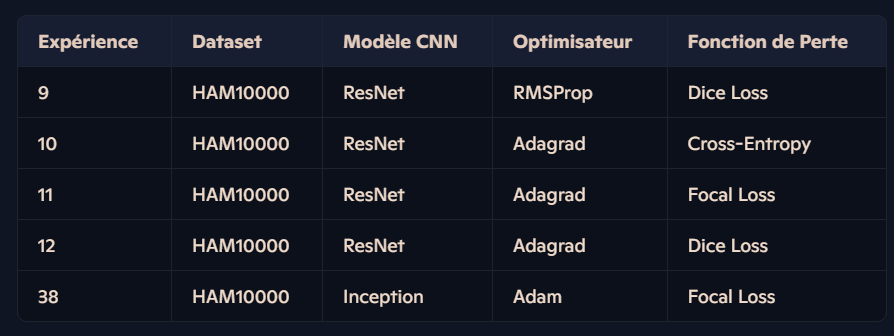

In [119]:
import os
import torch
from torch import nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
import pandas as pd
from glob import glob
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import warnings
from torchvision.models import Inception_V3_Weights

In [120]:
# Désactiver les warnings FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning)

In [121]:
# Configuration
np.random.seed(10)
torch.manual_seed(10)
if torch.cuda.is_available():
    torch.cuda.manual_seed(10)

In [122]:
# Chemins
DATA_DIR = '/kaggle/input/skin-cancer-mnist-ham10000'

In [123]:
class HAM10000Dataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        img_path = self.df['path'].iloc[index]
        image = Image.open(img_path)
        label = self.df['cell_type_idx'].iloc[index]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [124]:
def load_data():
    """Charge et prépare les données HAM10000"""
    all_image_path = glob(os.path.join(DATA_DIR, '*', '*.jpg'))
    imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in all_image_path}
    
    df_original = pd.read_csv(os.path.join(DATA_DIR, 'HAM10000_metadata.csv'))
    
    lesion_type_dict = {
        'nv': 'Melanocytic nevi',
        'mel': 'Melanoma',
        'bkl': 'Benign keratosis-like lesions',
        'bcc': 'Basal cell carcinoma',
        'akiec': 'Actinic keratoses',
        'vasc': 'Vascular lesions',
        'df': 'Dermatofibroma'
    }
    
    df_original['path'] = df_original['image_id'].map(imageid_path_dict.get)
    df_original['cell_type'] = df_original['dx'].map(lesion_type_dict.get)
    df_original['cell_type_idx'] = pd.Categorical(df_original['cell_type']).codes
    
    return df_original, lesion_type_dict

In [125]:
def initialize_model():
    """Initialise le modèle ResNet50"""
    model = models.resnet50(pretrained=False)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 7)
    return model

In [126]:
def initialize_inception_model():
    """Initialise un modèle InceptionV3."""
    model = models.inception_v3(weights=False, aux_logits=False)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 7)  # 7 classes pour ce dataset
    return model

In [127]:
def evaluate_model(model, dataloader, device, num_classes):
    """Évalue le modèle sur l'ensemble du dataset"""
    model.eval()
    all_predictions = []
    all_probabilities = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Évaluation"):
            images = images.to(device)
            outputs = model(images)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            
            all_probabilities.extend(probabilities.cpu().numpy())
            all_predictions.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())
            
    return np.array(all_labels), np.array(all_predictions), np.array(all_probabilities)

In [128]:
def evaluate_multiple_models(models_paths, dataloader, device, num_classes, class_names, model_type_dict):
    """Évalue plusieurs modèles et trace une courbe ROC globale pour chaque modèle."""
    roc_auc_all_models = {}
    
    plt.figure(figsize=(12, 8))
    
    for model_path in models_paths:
        # Identifier le type de modèle
        model_name = os.path.basename(model_path)
        print(f"\nÉvaluation du modèle: {model_name}")
        
        # Déterminer le type de modèle
        model_type = model_type_dict.get(model_path, 'resnet')
        if model_type == 'inception':  
            model = initialize_inception_model()
        else:
            model = initialize_model()
        
        # Charger les poids du modèle (strict=False pour ignorer les clés non utilisées)
        state_dict = torch.load(model_path, map_location=device, weights_only=True)  # Ajout de weights_only=True
        model.load_state_dict(state_dict, strict=False)  # Ignorer les clés supplémentaires
        
        model = model.to(device)
        
        # Évaluer le modèle
        y_true, y_pred, y_prob = evaluate_model(model, dataloader, device, num_classes)
        
        # Calcul de la courbe ROC moyenne
        y_true_bin = label_binarize(y_true, classes=range(num_classes))
        fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
        roc_auc = auc(fpr, tpr)
        roc_auc_all_models[model_name] = roc_auc
        
        # Tracer la courbe ROC globale
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    
    # Ajouter la ligne de référence
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taux de faux positifs')
    plt.ylabel('Taux de vrais positifs')
    plt.title('Courbes ROC globales pour chaque modèle')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()
    
    return roc_auc_all_models

       

Chargement des données...
Évaluation des modèles...

Évaluation du modèle: model_exp9.pth


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Évaluation: 100%|██████████| 313/313 [00:41<00:00,  7.53it/s]
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The


Évaluation du modèle: model_exp10.pth


Évaluation: 100%|██████████| 313/313 [00:41<00:00,  7.63it/s]
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



Évaluation du modèle: model_exp11.pth


Évaluation: 100%|██████████| 313/313 [00:40<00:00,  7.67it/s]
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



Évaluation du modèle: model_exp12.pth


Évaluation: 100%|██████████| 313/313 [00:40<00:00,  7.70it/s]
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



Évaluation du modèle: model_exp39.pth


Évaluation: 100%|██████████| 313/313 [00:40<00:00,  7.70it/s]


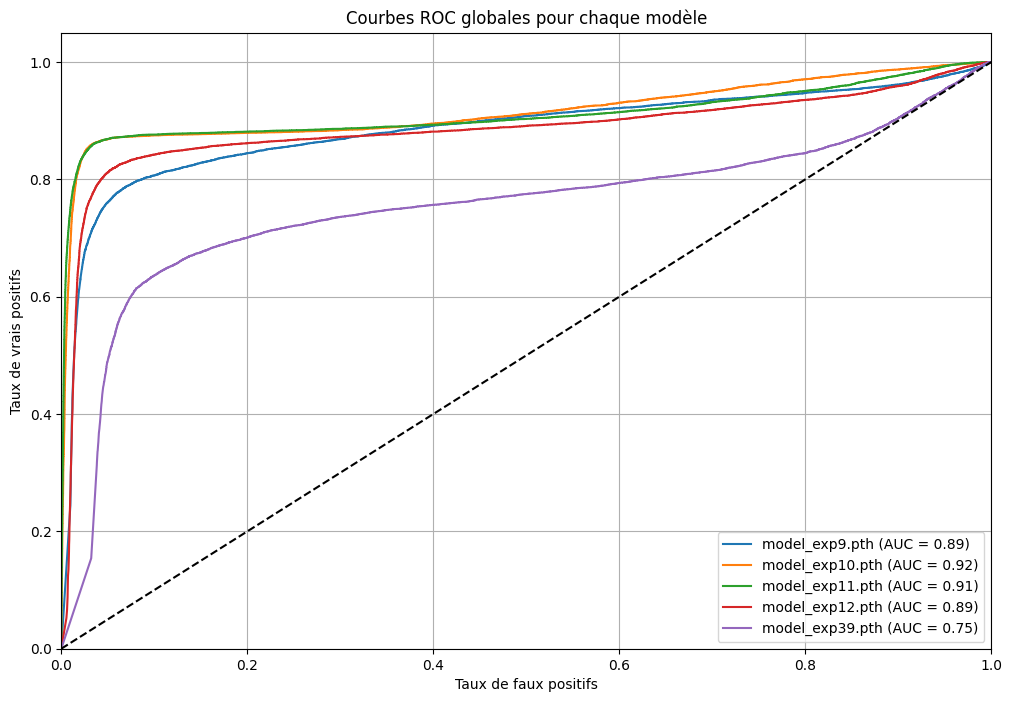


AUC des modèles :
model_exp9.pth: AUC = 0.8852
model_exp10.pth: AUC = 0.9162
model_exp11.pth: AUC = 0.9105
model_exp12.pth: AUC = 0.8851
model_exp39.pth: AUC = 0.7531


In [129]:
def main_multiple_models():
    # Paramètres
    input_size = 224
    norm_mean = [0.7630392, 0.5456477, 0.57004845]
    norm_std = [0.1409286, 0.15261266, 0.16997074]
    batch_size = 32
    
    # Transformations
    transform = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize(norm_mean, norm_std)
    ])
    
    # Exemple d'association explicite des chemins aux types de modèles
    model_type_dict = {
        '/kaggle/input/exp-n9-ham10000-resnet-rmsprop-dice-loss/model_exp9.pth': 'resnet',
        '/kaggle/input/exp-n10-ham10000-resnet-adagrad-crossentropy/model_exp10.pth': 'resnet',
        '/kaggle/input/exp-n11-ham10000-resnet-adagrad-focalloss/model_exp11.pth': 'resnet',
        '/kaggle/input/exp-n12-ham10000-resnet-adagrad-dice-loss/model_exp12.pth': 'resnet',
        '/kaggle/input/exp-n39-ham10000-inception-adam-dice-loss/model_exp39.pth': 'inception'  
    }
    
    try:
        # Charger les données
        print("Chargement des données...")
        df, lesion_type_dict = load_data()
        
        # Créer le dataset et dataloader
        dataset = HAM10000Dataset(df, transform=transform)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4)
        
        # Liste des modèles à évaluer
        models_paths = list(model_type_dict.keys())  # Charger les chemins des modèles
        
        # Évaluer les modèles
        print("Évaluation des modèles...")
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        class_names = list(lesion_type_dict.values())
        roc_auc_all_models = evaluate_multiple_models(models_paths, dataloader, device, len(class_names), class_names, model_type_dict)
        
        print("\nAUC des modèles :")
        for model_name, auc_value in roc_auc_all_models.items():
            print(f"{model_name}: AUC = {auc_value:.4f}")
        
    except Exception as e:
        print(f"Erreur: {str(e)}")

if __name__ == "__main__":
    main_multiple_models()